In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import sys

sys.path.append('../..')
from src import SpectralFunctions

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=True)

S_F = SpectralFunctions.Spectral_Funcs()

In [2]:
from src import IOFunctions

IO = IOFunctions.IO_Functions()

In [3]:
R, G, B, wavelength = S_F.getpixelefficiency('/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Code/Python/pyBayerSMLM/Spectra/Camera_QE/CS505CU_QE.csv')

In [5]:
single_molecule_dyes = ['Alexa Fluor 488', 'ATTO 488', 'CF505', 'CF500', 'CF680', 'ATTO 520', 'Alexa Fluor 514', 'ATTO 514',
                        'Rhodamine 6G', 'Alexa Fluor 532', 'BODIPY TMR', 'Alexa Fluor 546', 'ATTO 565',
                        'Alexa Fluor 568', 'Alexa Fluor 594', 'Alexa Fluor 610', 'ATTO 594', 'Alexa Fluor 633',
                        'ATTO 495', 'ATTO 633', 'ATTO 647N', 'ATTO 725', 'ATTO 740', 'ATTO 655', 'ATTO 680', 'ATTO 700',
                        'Cy3B', 'Cy3.5', 'Cy5', 'Alexa Fluor 647', 'Cy5.5', 'Alexa Fluor 680', 'Alexa Fluor 700',
                        'Cy7', 'LD 655', 'Qdot 705', 'Qdot 655', 'JF657', 'CF488A', 'Janelia Fluor JF585-HaloTag conjugate', 'CF568', 'ATTO 643', 
                       'CF640R', 'CF660R', 'abberior STAR 635P', 'Cy2', 'Tetramethylrhodamine (TAMRA, TRITC)', 'Cy7', 'Alexa Fluor 750', 'Alexa Fluor 790']

In [ ]:
for dye in single_molecule_dyes:
    print(dye)
    S_F.get_pixel_fractions_dye_and_filters(dyes=dye, filters=[], wavelength=wavelength, pixel_QYs=np.vstack([R, G, B]))

In [ ]:
average_wavelengths, RGB_ideal = S_F.get_pixel_fractions_dye_and_filters(dyes=single_molecule_dyes, filters=[], wavelength=wavelength, pixel_QYs=np.vstack([R, G, B]))
RGB_ideal = RGB_ideal.T/np.sum(RGB_ideal, axis=1)
RGB_ideal = RGB_ideal.T

In [7]:
single_molecule_dyes_example = ['ATTO 488', 'ATTO 550', 'ATTO 647N']

In [12]:
average_wavelengths, RGB_ATTOs = S_F.get_pixel_fractions_dye_and_filters(dyes=single_molecule_dyes_example, filters=[], wavelength=wavelength, pixel_QYs=np.vstack([R, G, B]))
RGB_ATTOs = RGB_ATTOs.T/np.sum(RGB_ATTOs, axis=1)
RGB_ATTOs = RGB_ATTOs.T

In [13]:
colours = ['#99ff99', '#ffc04d', '#ff6666']

In [19]:
spectrum = np.squeeze(S_F.get_dye_or_filter_data(names=['ATTO 488'], wavelength=wavelength))


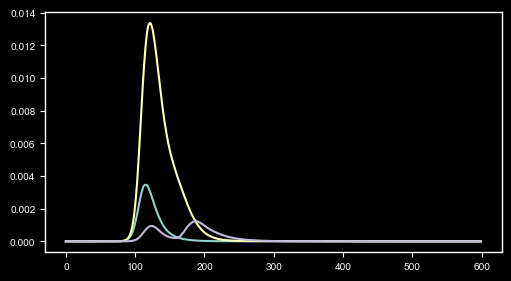

In [20]:
plt.plot(spectrum * B)
plt.plot(spectrum * G)
plt.plot(spectrum * R)

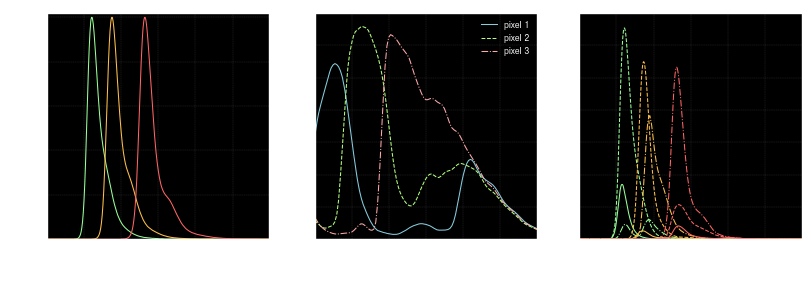

In [45]:
fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1,1,1], width=8, height=2.7)

for i, dye in enumerate(single_molecule_dyes_example):
    spectrum = np.squeeze(S_F.get_dye_or_filter_data(names=dye, wavelength=wavelength))
    spectrum = spectrum/np.max(spectrum)
    axs[0] = plotter.line_plot(axs=axs[0], x=wavelength, y=spectrum, color=colours[i], xaxislabel='wavelength', yaxislabel='fluo/norm.')
    
    axs[2] = plotter.line_plot(axs=axs[2], x=wavelength, y=100*spectrum*B, color=colours[i], xaxislabel='wavelength', yaxislabel='fluorescence on pixel/norm.')
    axs[2] = plotter.line_plot(axs=axs[2], x=wavelength, y=100*spectrum*G, color=colours[i], xaxislabel='wavelength', yaxislabel='fluorescence on pixel/norm.', ls='--')
    axs[2] = plotter.line_plot(axs=axs[2], x=wavelength, y=100*spectrum*R, color=colours[i], xaxislabel='wavelength', yaxislabel=r'fluorescence on pixel/%.', ls='-.')
  
axs[0].set_ylim([0, 1.02])
axs[2].set_ylim([0, 70])


axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=B, color='#87cddec7', alpha=1, xaxislabel='wavelength', yaxislabel='QE', label='pixel 1')
axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=G, color='#b3ff80ff', alpha=1, ls='--', xaxislabel='wavelength', yaxislabel='QE', label='pixel 2')
axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=R, color='#ffaaaaff', alpha=1, ls='-.', xaxislabel='wavelength', yaxislabel='QE', label='pixel 3')
axs[1].set_ylim([0, 0.7])
axs[1].legend(loc='best', fontsize=6, frameon=False)

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/dyes/'
plt.savefig(os.path.join(folder, "ThreeSMDyes_Spectra_All.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1], width=5, height=2.7)

for i, dye in enumerate(single_molecule_dyes):
    spectrum = np.squeeze(S_F.get_dye_or_filter_data(names=dye, wavelength=wavelength))
    spectrum = spectrum/np.max(spectrum)
    axs[0] = plotter.line_plot(axs=axs[0], x=wavelength, y=spectrum, color=c[:, i], xaxislabel='wavelength', yaxislabel='fluo/norm.')
axs[0].set_ylim([0, 1.02])


axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=B, color='white', xaxislabel='wavelength', yaxislabel='QE', label='pixel 1')
axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=G, color='white', ls='--', xaxislabel='wavelength', yaxislabel='QE', label='pixel 2')
axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=R, color='white', ls='-.', xaxislabel='wavelength', yaxislabel='QE', label='pixel 3')
axs[1].set_ylim([0, 0.7])
axs[1].legend(loc='best', fontsize=6, frameon=False)

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/dyes/'
plt.savefig(os.path.join(folder, "AllSMDyes_Spectra.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

import matplotlib.pyplot as plt
import mpltern
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


fig, ax = plotter.two_column_plot()
ax = fig.add_subplot(1, 1, 1, projection="ternary")

ax.taxis.set_major_locator(MultipleLocator(0.2))
ax.laxis.set_major_locator(MultipleLocator(0.2))
ax.raxis.set_major_locator(MultipleLocator(0.2))

ax.taxis.set_minor_locator(MultipleLocator(0.1))
ax.laxis.set_minor_locator(MultipleLocator(0.1))
ax.raxis.set_minor_locator(MultipleLocator(0.1))

# Color ticks, grids, tick-labels

ax.set_tlabel(r"pixel 1/%")
ax.set_llabel(r"pixel 3/%")
ax.set_rlabel(r"pixel 2/%")

ax.grid(lw=0.5, alpha=0.25, ls="--", which="both", axis="both")

Rd = RGB_ideal[:, 0]*100
Gd = RGB_ideal[:, 1]*100
Bd = RGB_ideal[:, 2]*100
c = np.vstack([RGB_ideal.T, np.ones_like(Rd)])

pc = ax.scatter(
    Rd, Gd, Bd, s=10, facecolors=colours, edgecolors="None", lw=0, marker="o"
)

ax.set_tlim(0, 100)
ax.set_llim(0, 100)
ax.set_rlim(0, 100)

plt.style.use('dark_background')

plt.tight_layout()

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/dyes/'
plt.savefig(os.path.join(folder, "Chromophores_PixelIntensity_SMDyes.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

import matplotlib.pyplot as plt
import mpltern
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

average_wavelengths, RGB_example = S_F.get_pixel_fractions_dye_and_filters(dyes=single_molecule_dyes_example, filters=[], wavelength=wavelength, pixel_QYs=np.vstack([R, G, B]))
RGB_example = RGB_example.T/np.sum(RGB_example, axis=1)
RGB_example = RGB_example.T

fig, ax = plotter.two_column_plot()
ax = fig.add_subplot(1, 1, 1, projection="ternary")

ax.taxis.set_major_locator(MultipleLocator(0.2))
ax.laxis.set_major_locator(MultipleLocator(0.2))
ax.raxis.set_major_locator(MultipleLocator(0.2))

ax.taxis.set_minor_locator(MultipleLocator(0.1))
ax.laxis.set_minor_locator(MultipleLocator(0.1))
ax.raxis.set_minor_locator(MultipleLocator(0.1))

# Color ticks, grids, tick-labels

ax.set_tlabel(r"pixel 1/%")
ax.set_llabel(r"pixel 3/%")
ax.set_rlabel(r"pixel 2/%")

ax.grid(lw=0.5, alpha=0.25, ls="--", which="both", axis="both")

Rd = RGB_example[:, 0]*100
Gd = RGB_example[:, 1]*100
Bd = RGB_example[:, 2]*100

pc = ax.scatter(
    Rd, Gd, Bd, s=10, facecolors=colours, edgecolors="None", lw=0, marker="o"
)

ax.set_tlim(0, 100)
ax.set_llim(0, 100)
ax.set_rlim(0, 100)

plt.style.use('dark_background')

plt.tight_layout()

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/dyes/'
plt.savefig(os.path.join(folder, "Chromophores_PixelIntensity_ThreeSMDyes.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
# let's make a few (arbitrary) dyes
# make some dyes at different colours
# dye_width = 30 # 30 nm peak width
# dye_abs_skew = -5 # absorption spectral skew
# dye_em_skew = 3 # emission spectral skew
# Abs_450 = Gau_gen.SkewGaussian_wavelength(dye_width, dye_abs_skew, 440, wavelength); Em_450 = Gau_gen.SkewGaussian_wavelength(dye_width, dye_em_skew, 450, wavelength)
# Abs_500 = Gau_gen.SkewGaussian_wavelength(dye_width, dye_abs_skew, 490, wavelength); Em_500 = Gau_gen.SkewGaussian_wavelength(dye_width, dye_em_skew, 500, wavelength)
# Abs_647 = Gau_gen.SkewGaussian_wavelength(dye_width, dye_abs_skew, 640, wavelength); Em_647 = Gau_gen.SkewGaussian_wavelength(dye_width, dye_em_skew, 650, wavelength)

# visualise them, and our pixel efficiencies
fig, ax = plotter.one_column_plot(height=2)
ax.plot(wavelength, B, color="white", lw=2, ls="--", label='pixel 1')
ax.plot(wavelength, G, color="white", lw=2, ls=":", label='pixel 2')
ax.plot(wavelength, R, color="white", lw=2, ls="-.", label='pixel 3')

plt.xlim([400, 760])
ax.set_ylim([0, 1])
plt.grid(lw=0.5, ls="--", color="gray", alpha=0.5)
plt.grid(alpha=0.5, lw=0.25)
plt.xlabel("wavelength/nm")
ax.set_ylabel("camera QE")
plt.legend(loc='best')
folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Cambridge_Enterprise/20241204/fig/multicolour_camera/dyes'
plt.savefig(os.path.join(folder, "Camera_QE.svg"), format="svg", dpi=600)

plt.show(block=False)  # plot all the absorptions and emissions we have

In [ ]:
# put dyes into array
dyes = np.dstack([[Abs_450, Em_450], [Abs_500, Em_500], [Abs_647, Em_647]])

# describe our laser wavelengths
lasers = np.array([420, 488, 640])

# describe our laser intensities
intensity_1 = np.array([1, 1, 1])
intensity_2 = np.array([1, 0, 0])
laser_int = np.vstack([lasers, intensity_1, intensity_2])

In [ ]:
# get raw images, demosaiced images, and gain map
gain_value = 1  # gain value
n_photons = np.array([4000, 4000, 4000])  # number of photons per dye
ol = deepcopy(object_locs)

raw_images, colour_image_demosaic, gain_map = IG.gen_camera_images(
    gain_value,
    wavelength,
    R,
    G,
    B,
    dyes,
    n_photons,
    laser_int,
    ol,
    object_sigma=5,
    background_photons=150,
    image_h=1280,
    image_w=1024,
    pixel_shift=50,
)

In [ ]:
# why don't we plot all of these images
fig = plt.figure()

ax1 = plt.subplot2grid(shape=(3, 2), loc=(0, 0), colspan=1)
ax2 = plt.subplot2grid(shape=(3, 2), loc=(1, 0), colspan=1)
ax3 = plt.subplot2grid(shape=(3, 2), loc=(2, 0), colspan=1)
ax4 = plt.subplot2grid((3, 2), (0, 1), rowspan=3)

ax1.imshow(raw_images.values[0, :, :, 0])  # let's plot the red channel
ax1.scatter(
    object_locs[:, 1, 2], object_locs[:, 0, 2], s=5, lw=0, color="white", alpha=0.5
)
ax1.set_xticklabels([])
ax1.set_yticklabels([])

ax2.imshow(raw_images.values[0, :, :, 1])  # let's plot the green channel
ax2.scatter(
    object_locs[:, 1, 1], object_locs[:, 0, 1], s=5, lw=0, color="white", alpha=0.5
)
ax2.set_xticklabels([])
ax2.set_yticklabels([])

ax3.imshow(raw_images.values[0, :, :, 2])  # let's plot the blue channel
ax3.scatter(
    object_locs[:, 1, 0], object_locs[:, 0, 0], s=5, lw=0, color="white", alpha=0.5
)
ax3.set_xticklabels([])
ax3.set_yticklabels([])

toplot = colour_image_demosaic.values[0, :, :, :] / np.max(
    colour_image_demosaic.values[0, :, :, :]
)
ax4.imshow(toplot, vmin=0, vmax=1)
ax4.set_xticklabels([])
ax4.set_yticklabels([])

plt.tight_layout()
# plt.savefig('/home/jbeckwith/Documents/Dropbox (Cambridge University)/Chemistry/Lee/Talks+Posters/Subgroup/20230720/fig/Example_Caroline_Data.svg', format='svg', dpi=600, transparent=False, bbox_inches='tight')
plt.show(block=False)

In [ ]:
# and now let's plot our two images from 2 separate laser shot combinations side-by-side
fig = plt.figure()

ax3 = plt.subplot2grid(shape=(3, 2), loc=(0, 0), rowspan=3)
ax4 = plt.subplot2grid((3, 2), loc=(0, 1), rowspan=3)

toplot = colour_image_demosaic.values[0, :, :, :] / np.max(
    colour_image_demosaic.values[0, :, :, :]
)
ax3.imshow(toplot, vmin=0.1, vmax=0.9)  # let's plot the blue channel
ax3.set_xticklabels([])
ax3.set_yticklabels([])

toplot = colour_image_demosaic.values[1, :, :, :] / np.max(
    colour_image_demosaic.values[1, :, :, :]
)
ax4.imshow(toplot, vmin=0.1, vmax=0.9)
ax4.set_xticklabels([])
ax4.set_yticklabels([])

plt.tight_layout()
plt.show(block=False)